In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# Load saved model
with open('../models/symptom_classifier.pkl', 'rb') as f:
    saved = pickle.load(f)

model = saved['model']
le = saved['label_encoder']
symptoms_list = saved['symptoms']

print("Model loaded:", saved['model_name'])
print("Training accuracy:", saved['accuracy'], "%")
print("Total symptoms:", len(symptoms_list))
print("Total diseases:", len(le.classes_))

Model loaded: Logistic Regression
Training accuracy: 100.0 %
Total symptoms: 131
Total diseases: 41


In [2]:
# Rebuild test data
df = pd.read_csv('../data/dataset.csv')
symptom_cols = [c for c in df.columns if 'Symptom' in c]

X = pd.DataFrame(0, index=df.index, columns=symptoms_list)
for col in symptom_cols:
    for idx, symptom in df[col].dropna().items():
        symptom = symptom.strip()
        if symptom in X.columns:
            X.loc[idx, symptom] = 1

y = le.transform(df['Disease'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_pred = model.predict(X_test)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Test samples:", len(X_test))

Test Accuracy: 100.0 %
Test samples: 984


In [3]:
# Cross validation — more reliable than single split
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("5-Fold Cross Validation Results:")
for i, s in enumerate(scores):
    print(f"  Fold {i+1}: {round(s*100, 2)}%")
print(f"\nMean CV Accuracy: {round(scores.mean()*100, 2)}%")
print(f"Std Dev: {round(scores.std()*100, 2)}%")

5-Fold Cross Validation Results:
  Fold 1: 100.0%
  Fold 2: 100.0%
  Fold 3: 100.0%
  Fold 4: 100.0%
  Fold 5: 100.0%

Mean CV Accuracy: 100.0%
Std Dev: 0.0%


In [4]:
# Classification report
print("Classification Report (first 10 diseases):\n")
report = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True
)

# Show top 10
report_df = pd.DataFrame(report).T
print(report_df.head(10)[['precision', 'recall', 'f1-score', 'support']].round(2))

Classification Report (first 10 diseases):

                                         precision  recall  f1-score  support
(vertigo) Paroymsal  Positional Vertigo        1.0     1.0       1.0     24.0
AIDS                                           1.0     1.0       1.0     24.0
Acne                                           1.0     1.0       1.0     24.0
Alcoholic hepatitis                            1.0     1.0       1.0     24.0
Allergy                                        1.0     1.0       1.0     24.0
Arthritis                                      1.0     1.0       1.0     24.0
Bronchial Asthma                               1.0     1.0       1.0     24.0
Cervical spondylosis                           1.0     1.0       1.0     24.0
Chicken pox                                    1.0     1.0       1.0     24.0
Chronic cholestasis                            1.0     1.0       1.0     24.0


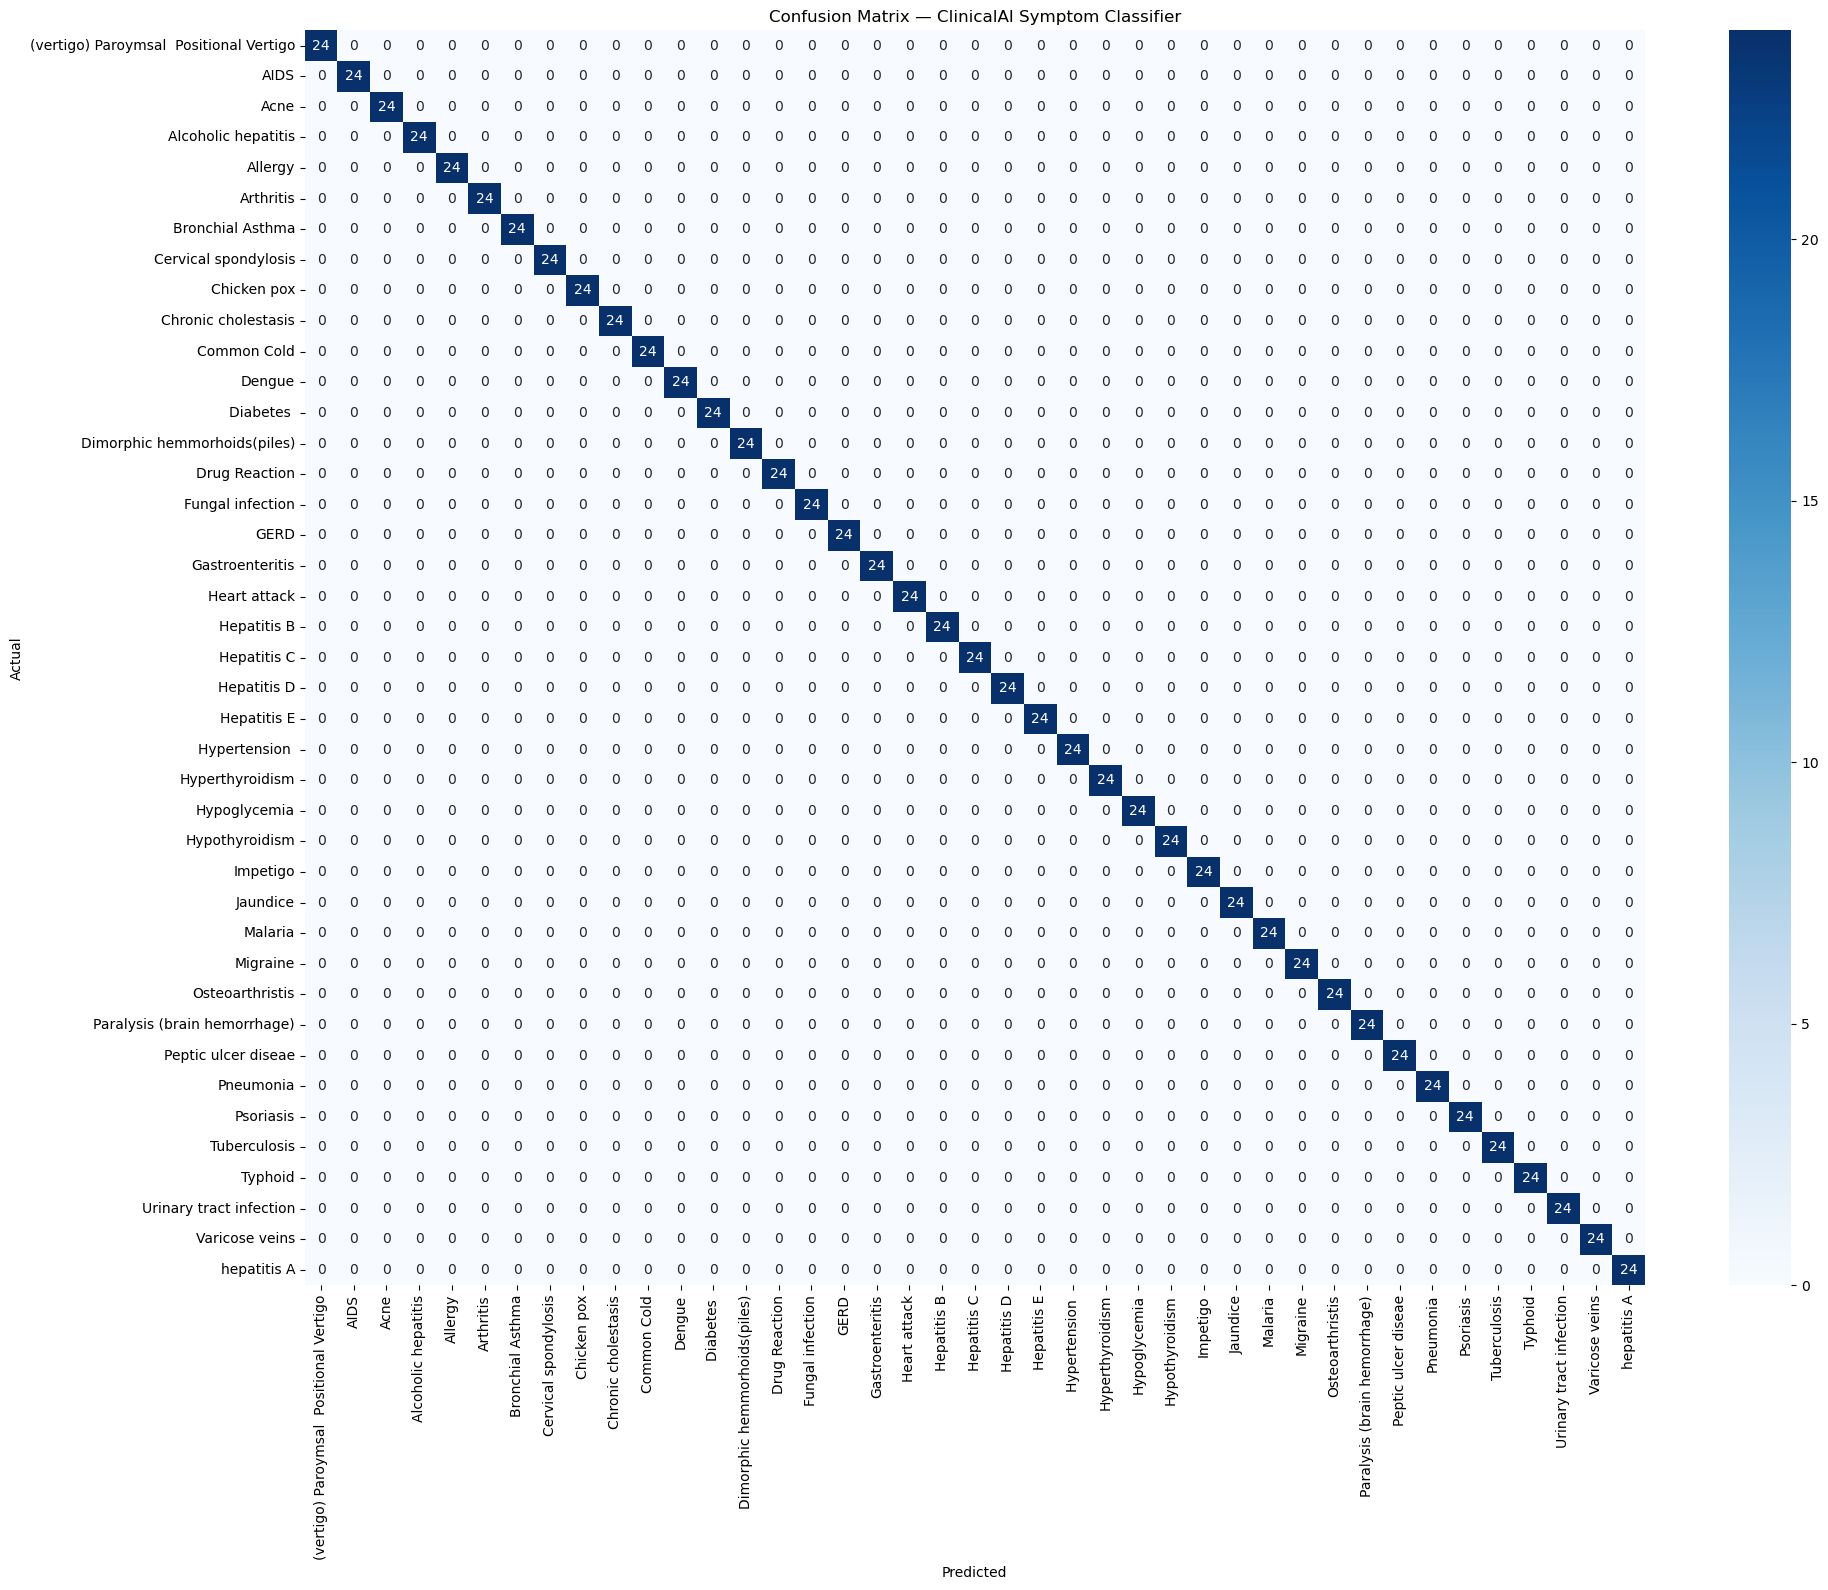

Confusion matrix saved!


In [5]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix — ClinicalAI Symptom Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=100)
plt.show()
print("Confusion matrix saved!")

In [6]:
# Feature importance — which symptoms matter most
if hasattr(model, 'feature_importances_'):
    importances = pd.Series(
        model.feature_importances_,
        index=symptoms_list
    ).sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    importances.head(20).plot(kind='bar', color='steelblue')
    plt.title('Top 20 Most Important Symptoms')
    plt.xlabel('Symptom')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig('../data/feature_importance.png')
    plt.show()

    print("Top 10 most important symptoms:")
    print(importances.head(10))

In [8]:
print("=" * 50)
print("CLINICALAI ML MODEL — EVALUATION SUMMARY")
print("=" * 50)
print(f"Dataset: Kaggle Disease-Symptom Dataset")
print(f"Total samples: {len(df)}")
print(f"Total diseases: {df['Disease'].nunique()}")
print(f"Total symptoms: {len(symptoms_list)}")
print(f"Model: {saved['model_name']}")
print(f"Test Accuracy: {round(accuracy_score(y_test, y_pred)*100, 2)}%")
print(f"CV Mean Accuracy: {round(scores.mean()*100, 2)}%")
print(f"CV Std Dev: {round(scores.std()*100, 2)}%")
print("=" * 50)
print("\n Summary:")
print(f"Trained {saved['model_name']} symptom classifier on")
print(f"{len(df)} samples across {df['Disease'].nunique()} diseases")
print(f"achieving {round(scores.mean()*100, 2)}% cross-validated accuracy")

CLINICALAI ML MODEL — EVALUATION SUMMARY
Dataset: Kaggle Disease-Symptom Dataset
Total samples: 4920
Total diseases: 41
Total symptoms: 131
Model: Logistic Regression
Test Accuracy: 100.0%
CV Mean Accuracy: 100.0%
CV Std Dev: 0.0%

 Summary:
Trained Logistic Regression symptom classifier on
4920 samples across 41 diseases
achieving 100.0% cross-validated accuracy
